1-D scan (fish_rate): 40/40 complete


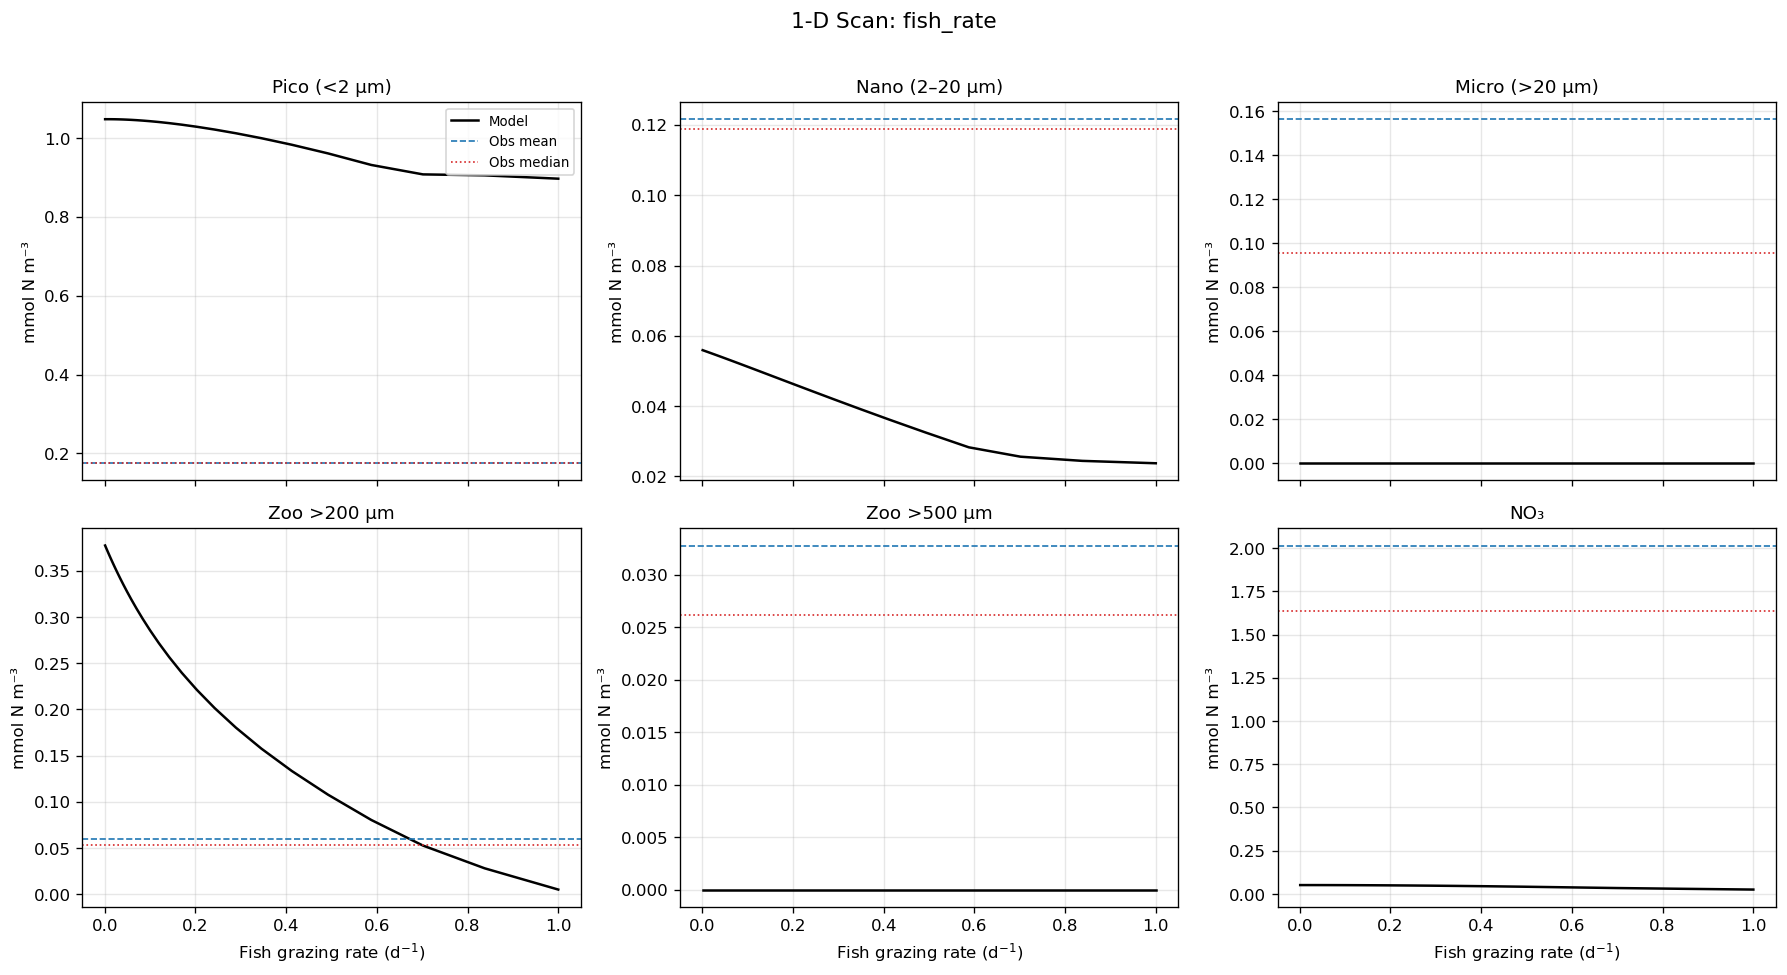

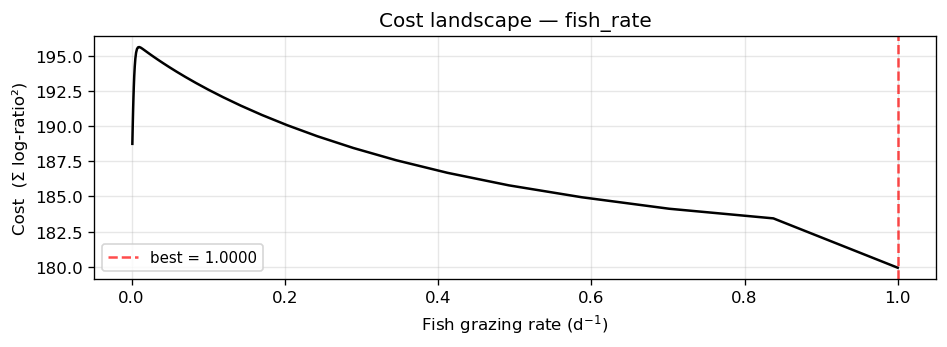

Cost = 179.9362

        Component       Model    Obs Mean     Ratio
  --------------------------------------------------
      micro_phyto     0.00000     0.15627      0.00x
       nano_phyto     0.02374     0.12162      0.20x
       pico_phyto     0.89692     0.17506      5.12x
        zoo_gt200     0.00497     0.05934      0.08x
        zoo_gt500     0.00000     0.03280      0.00x
              NO3     0.02519     2.01581      0.01x

  Parameters:
          fish_rate = 1.000000


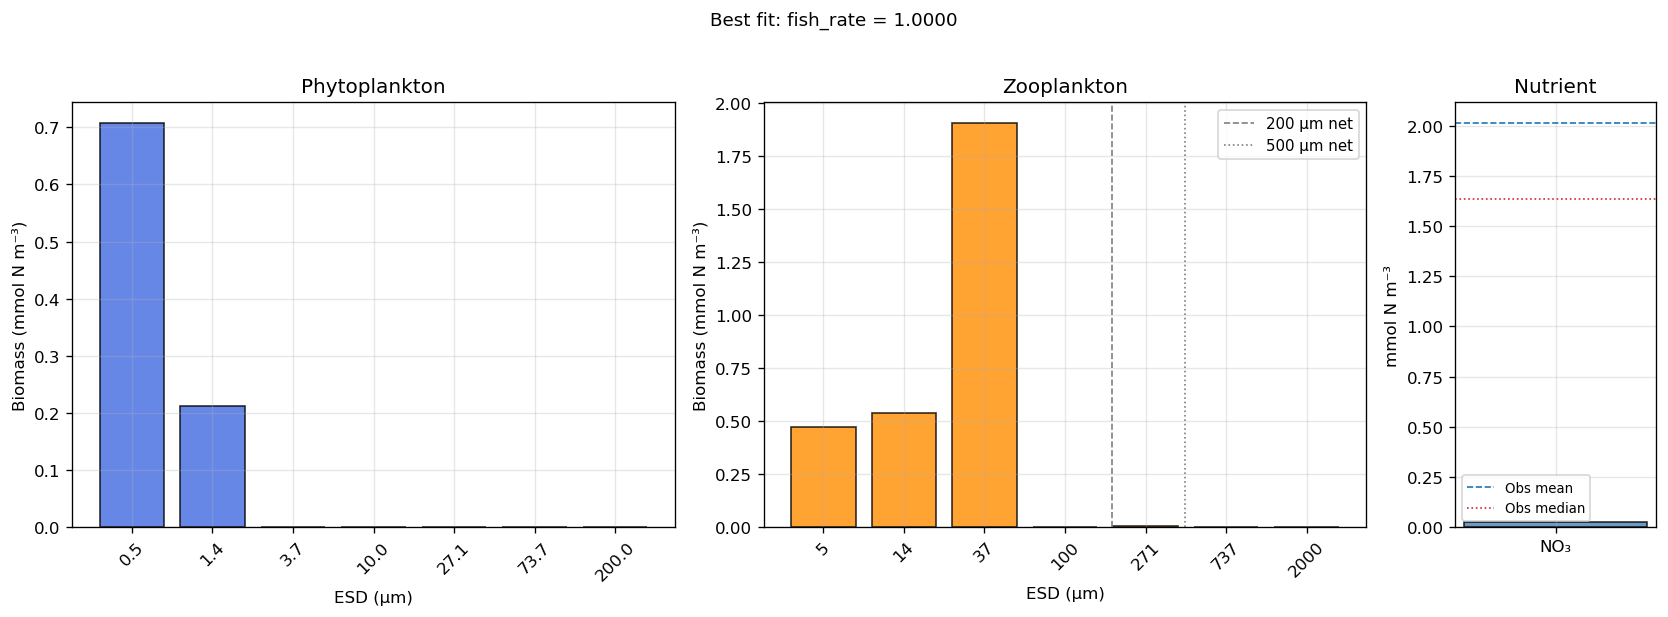

In [8]:
# %% [markdown]
# # 1-D Parameter Scans
#
# Sweep one parameter at a time across its range,
# keeping all others at the CARIACO baseline.

# %% ── Imports ───────────────────────────────────────────────────────
import numpy as np
from cariaco_scan_utils import (
    PARAM_DEFS, run_1d_scan,
    plot_1d_components, plot_cost_curve, plot_spectrum,
    print_fit_summary,
)

# %% ── Available parameters ─────────────────────────────────────────
for name, p in PARAM_DEFS.items():
    tag = '(derived)' if p['xso_name'] is None else ''
    print(f"  {name:>15s}:  range {p['range']}  default={p['default']}  {tag}")

# %% ── Configure & run a single 1-D scan ────────────────────────────
#
#  Change SCAN_PARAM and SCAN_RANGE to explore different parameters.
#  fixed_params lets you override other parameters during the scan
#  (e.g. hold fish_rate at a candidate value while scanning KsZ).

SCAN_PARAM = 'fish_rate'
SCAN_RANGE = np.logspace(np.log10(0.001), np.log10(1.0), 40)
FIXED      = {}          # e.g. {'fish_rate': 1.0, 'mZ': 0.05}
N_PROCS    = 20

results = run_1d_scan(
    SCAN_PARAM, SCAN_RANGE,
    fixed_params=FIXED,
    n_procs=N_PROCS,
)

# %% ── Visualise ────────────────────────────────────────────────────
plot_1d_components(results, SCAN_PARAM)
plot_cost_curve(results, SCAN_PARAM)

# %% ── Best-fit size spectrum ────────────────────────────────────────
best = min(results, key=lambda r: r['cost'])
print_fit_summary(best)
plot_spectrum(best, title=f"Best fit: {SCAN_PARAM} = {best['params'][SCAN_PARAM]:.4f}")

# %% ── Batch: run ALL 1-D scans & rank top 5 globally ───────────────
#
#  Uncomment and run this cell to sweep every parameter and report
#  the single best point found across all scans.

# all_results = []
# for name, pdef in PARAM_DEFS.items():
#     lo, hi = pdef['range']
#     vals = np.linspace(lo, hi, 30)
#     res = run_1d_scan(name, vals, n_procs=N_PROCS)
#     all_results.extend(res)
#
# all_results.sort(key=lambda r: r['cost'])
# from cariaco_scan_utils import print_top_fits
# print_top_fits(all_results, n=5)
# plot_spectrum(all_results[0])

In [7]:
np.logspace(0.1, 3.0, 1,2)

array([1.25892541])

In [ ]:
# %% ── Imports ───────────────────────────────────────────────────────
import numpy as np
from cariaco_scan_utils import (
    run_1d_scan,
    plot_1d_components, plot_cost_curve, plot_spectrum,
    print_fit_summary, print_top_fits,
)

# %% ── Define all 1-D scans ─────────────────────────────────────────
SCANS_1D = {
    'KsZ':          np.linspace(0.1, 10.0, 40),
    'mZ':           np.linspace(0.001, 0.5, 40),
    'N0':           np.linspace(1.0, 15.0, 40),
    'dilution':     np.linspace(0.005, 0.1, 40),
    'fish_biomass': np.linspace(0.0, 1.0, 40),
    'fish_rate':    np.linspace(0.001, 2.0, 40),
}

N_PROCS = 20
FIXED   = {}   # hold other params at candidate values, e.g. {'mZ': 0.05}

# %% ── Run a single scan ────────────────────────────────────────────
SCAN_NAME = 'KsZ'

results = run_1d_scan(SCAN_NAME, SCANS_1D[SCAN_NAME],
                      fixed_params=FIXED, n_procs=N_PROCS)

plot_1d_components(results, SCAN_NAME)
plot_cost_curve(results, SCAN_NAME)

best = min(results, key=lambda r: r['cost'])
print_fit_summary(best)
plot_spectrum(best, title=f"Best: {SCAN_NAME} = {best['params'][SCAN_NAME]:.4f}")

# %% ── Batch: run ALL scans & rank globally ──────────────────────────
all_results = []
for name, vals in SCANS_1D.items():
    res = run_1d_scan(name, vals, fixed_params=FIXED, n_procs=N_PROCS)
    all_results.extend(res)

print_top_fits(all_results, n=10)
plot_spectrum(min(all_results, key=lambda r: r['cost']))